In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import itertools
import statsmodels.api as sm

In [2]:
df = pd.read_excel('SuperStore Sales DataSet.xlsx')


In [3]:
df

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.940,1,28.2668,0,Online
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,0,Online
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.980,2,67.2742,0,Cards
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.460,2,28.6150,0,Online
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.080,2,-5.2640,0,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,907,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",213.136,4,12.1176,0,COD
5897,1297,CA-2020-115427,2020-12-30,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",295.904,2,4.5188,1,Online
5898,5092,CA-2020-156720,2020-12-30,2021-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,388.024,3,-0.6048,0,Online
5899,909,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,462.776,3,19.7910,0,COD




```
`# This is formatted as code`
```

## Basic EDA (Exploratory Data Analysis)


In [4]:
df['Category'].value_counts()

Category
Office Supplies    3569
Furniture          1249
Technology         1083
Name: count, dtype: int64

In [5]:
df.info

<bound method DataFrame.info of       Row ID+O6G3A1:R6        Order ID Order Date  Ship Date       Ship Mode  \
0                 4918  CA-2019-160304 2019-01-01 2019-01-07  Standard Class   
1                 4919  CA-2019-160304 2019-01-02 2019-01-07  Standard Class   
2                 4920  CA-2019-160304 2019-01-02 2019-01-07  Standard Class   
3                 3074  CA-2019-125206 2019-01-03 2019-01-05     First Class   
4                 8604  US-2019-116365 2019-01-03 2019-01-08  Standard Class   
...                ...             ...        ...        ...             ...   
5896               907  CA-2020-143259 2020-12-30 2021-01-03  Standard Class   
5897              1297  CA-2020-115427 2020-12-30 2021-01-03  Standard Class   
5898              5092  CA-2020-156720 2020-12-30 2021-01-03  Standard Class   
5899               909  CA-2020-143259 2020-12-30 2021-01-03  Standard Class   
5900              5093  CA-2020-151450 2020-12-31 2021-01-04  Standard Class   

     Customer ID      Customer Name    Segment        Country           City  \
0       BM-11575      Brendan Murry  Corporate  United States   Gaithersburg   
1       BM-11575      Brendan Murry  Corporate  United States   Gaithersburg   
2       BM-11575      Brendan Murry  Corporate  United States   Gaithersburg   
3       LR-16915       Lena Radford   Consumer  United States    Los Angeles   
4       CA-12310  Christine Abelman  Corporate  United States    San Antonio   
...          ...                ...        ...            ...            ...   
5896    PO-18865  Patrick O'Donnell   Consumer  United States  New York City   
5897    EB-13975         Erica Bern  Corporate  United States      Fairfield   
5898    JM-15580      Jill Matthias   Consumer  United States       Loveland   
5899    PO-18865  Patrick O'Donnell   Consumer  United States  New York City   
5900    JM-15580      Jill Matthias   Consumer  United States       Loveland   

      ...   Region       Product ID         Category Sub-Category  \
0     ...     East  FUR-BO-10004709        Furniture    Bookcases   
1     ...     East  FUR-BO-10004709        Furniture    Bookcases   
2     ...     East  TEC-PH-10000455       Technology       Phones   
3     ...     West  OFF-ST-10003692  Office Supplies      Storage   
4     ...  Central  TEC-AC-10002217       Technology  Accessories   
...   ...      ...              ...              ...          ...   
5896  ...     East  FUR-BO-10003441        Furniture    Bookcases   
5897  ...     West  OFF-BI-10002103  Office Supplies      Binders   
5898  ...     West  OFF-FA-10003472  Office Supplies    Fasteners   
5899  ...     East  OFF-BI-10003684  Office Supplies      Binders   
5900  ...     West  OFF-FA-10003472  Office Supplies    Fasteners   

                                           Product Name     Sales  Quantity  \
0     Bush Westfield Collection Bookcases, Medium Ch...    73.940         1   
1     Bush Westfield Collection Bookcases, Medium Ch...   173.940         3   
2                                           GE 30522EE2   231.980         2   
3     Recycled Steel Personal File for Hanging File ...   114.460         2   
4                   Imation Clip USB flash drive - 8 GB    30.080         2   
...                                                 ...       ...       ...   
5896  Bush Westfield Collection Bookcases, Fully Ass...   213.136         4   
5897    Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl   295.904         2   
5898                                Bagged Rubber Bands   388.024         3   
5899               Wilson Jones Legal Size Ring Binders   462.776         3   
5900                                Bagged Rubber Bands  2975.510         3   

       Profit  Returns  Payment Mode  
0     28.2668        0        Online  
1     38.2668        0        Online  
2     67.2742        0         Cards  
3     28.6150        0        Online  
4     -5.2640        0        Online  
...       ...      ...           .

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID+O6G3A1:R6,5901.0,5022.422471,1.0,2486.0,5091.0,7456.0,9994.0,2877.977184
Order Date,5901,2020-02-29 01:53:57.620742144,2019-01-01 00:00:00,2019-09-11 00:00:00,2020-03-16 00:00:00,2020-09-14 00:00:00,2020-12-31 00:00:00,NaN
Ship Date,5901,2020-03-04 00:08:47.097102336,2019-01-05 00:00:00,2019-09-15 00:00:00,2020-03-19 00:00:00,2020-09-16 00:00:00,2021-01-05 00:00:00,NaN
Sales,5901.0,265.345589,0.836,71.976,128.648,265.17,9099.93,474.260645
Quantity,5901.0,3.781901,1.0,2.0,3.0,5.0,14.0,2.212917
Profit,5901.0,29.700408,-6599.978,1.7955,8.5025,28.615,8399.976,259.589138
Returns,5901.0,0.048636,0.0,0.0,0.0,0.0,1.0,0.215124


In [7]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        915
Paper          825
Furnishings    573
Phones         519
Storage        498
Art            465
Accessories    461
Chairs         355
Appliances     279
Labels         211
Tables         190
Envelopes      133
Bookcases      131
Fasteners      124
Supplies       119
Machines        65
Copiers         38
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Row ID+O6G3A1:R6    0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Profit              0
Returns             0
Payment Mode        0
dtype: int64

# Furniture Forecasting

In [9]:
furniture = df.loc[df['Category']== 'Furniture']

In [10]:
furniture.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.940,1,28.2668,0,Online
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,0,Online
7,9494,CA-2019-105207,2019-01-03,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,...,Central,FUR-TA-10000617,Furniture,Tables,Hon Practical Foundations 30 x 60 Training Tab...,1592.850,7,350.4270,0,COD
16,8031,CA-2019-158806,2019-01-07,2019-01-11,Standard Class,NM-18520,Neoma Murray,Consumer,United States,Amarillo,...,Central,FUR-FU-10004270,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",23.076,3,-10.9611,0,COD
18,6851,US-2019-100461,2019-01-08,2019-01-12,Standard Class,JO-15145,Jack O'Briant,Corporate,United States,Franklin,...,Central,FUR-BO-10002545,Furniture,Bookcases,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",1565.880,6,407.1288,0,Online


In [11]:
furniture.columns

Index(['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode'],
      dtype='object')

In [12]:
r_col = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Quantity', 'Discount', 'Profit']

In [13]:
furniture

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.940,1,28.2668,0,Online
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,0,Online
7,9494,CA-2019-105207,2019-01-03,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,...,Central,FUR-TA-10000617,Furniture,Tables,Hon Practical Foundations 30 x 60 Training Tab...,1592.850,7,350.4270,0,COD
16,8031,CA-2019-158806,2019-01-07,2019-01-11,Standard Class,NM-18520,Neoma Murray,Consumer,United States,Amarillo,...,Central,FUR-FU-10004270,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",23.076,3,-10.9611,0,COD
18,6851,US-2019-100461,2019-01-08,2019-01-12,Standard Class,JO-15145,Jack O'Briant,Corporate,United States,Franklin,...,Central,FUR-BO-10002545,Furniture,Bookcases,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",1565.880,6,407.1288,0,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5884,7636,US-2020-158526,2020-12-29,2021-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Louisville,...,South,FUR-CH-10004495,Furniture,Chairs,"Global Leather and Oak Executive Chair, Black",351.980,1,87.2842,0,COD
5886,1878,CA-2020-118885,2020-12-29,2021-01-02,Standard Class,JG-15160,James Galang,Consumer,United States,Los Angeles,...,West,FUR-CH-10002880,Furniture,Chairs,"Global High-Back Leather Tilter, Burgundy",119.568,4,-44.2764,0,COD
5888,7633,US-2020-158526,2020-12-29,2021-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Louisville,...,South,FUR-CH-10002602,Furniture,Chairs,DMI Arturo Collection Mission-style Design Woo...,460.840,8,314.0384,0,COD
5892,5458,CA-2020-130631,2020-12-29,2021-01-02,Standard Class,BS-11755,Bruce Stewart,Consumer,United States,Edmonds,...,West,FUR-FU-10004093,Furniture,Furnishings,Hand-Finished Solid Wood Document Frame,466.460,2,20.5380,1,COD


In [14]:
furniture = furniture.sort_values('Order Date')

In [15]:
furniture

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.940,1,28.2668,0,Online
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,0,Online
7,9494,CA-2019-105207,2019-01-03,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,...,Central,FUR-TA-10000617,Furniture,Tables,Hon Practical Foundations 30 x 60 Training Tab...,1592.850,7,350.4270,0,COD
16,8031,CA-2019-158806,2019-01-07,2019-01-11,Standard Class,NM-18520,Neoma Murray,Consumer,United States,Amarillo,...,Central,FUR-FU-10004270,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",23.076,3,-10.9611,0,COD
18,6851,US-2019-100461,2019-01-08,2019-01-12,Standard Class,JO-15145,Jack O'Briant,Corporate,United States,Franklin,...,Central,FUR-BO-10002545,Furniture,Bookcases,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",1565.880,6,407.1288,0,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5892,5458,CA-2020-130631,2020-12-29,2021-01-02,Standard Class,BS-11755,Bruce Stewart,Consumer,United States,Edmonds,...,West,FUR-FU-10004093,Furniture,Furnishings,Hand-Finished Solid Wood Document Frame,466.460,2,20.5380,1,COD
5883,7637,US-2020-158526,2020-12-29,2021-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Louisville,...,South,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,184.750,3,77.6250,0,COD
5881,5132,CA-2020-146626,2020-12-29,2021-01-05,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Anaheim,...,West,FUR-FU-10002501,Furniture,Furnishings,Nu-Dell Executive Frame,419.120,8,37.4144,0,COD
5884,7636,US-2020-158526,2020-12-29,2021-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Louisville,...,South,FUR-CH-10004495,Furniture,Chairs,"Global Leather and Oak Executive Chair, Black",351.980,1,87.2842,0,COD


In [16]:
furniture  = furniture.set_index('Order Date')

In [17]:
furniture

,Row ID+O6G3A1:R6,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
Order Date,,,,,,,,,,,,,,,,,,,,
2019-01-01,4918,CA-2019-160304,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.940,1,28.2668,0,Online
2019-01-02,4919,CA-2019-160304,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,0,Online
2019-01-03,9494,CA-2019-105207,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,Oklahoma,Central,FUR-TA-10000617,Furniture,Tables,Hon Practical Foundations 30 x 60 Training Tab...,1592.850,7,350.4270,0,COD
2019-01-07,8031,CA-2019-158806,2019-01-11,Standard Class,NM-18520,Neoma Murray,Consumer,United States,Amarillo,Texas,Central,FUR-FU-10004270,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",23.076,3,-10.9611,0,COD
2019-01-08,6851,US-2019-100461,2019-01-12,Standard Class,JO-15145,Jack O'Briant,Corporate,United States,Franklin,Wisconsin,Central,FUR-BO-10002545,Furniture,Bookcases,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",1565.880,6,407.1288,0,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-29,5458,CA-2020-130631,2021-01-02,Standard Class,BS-11755,Bruce Stewart,Consumer,United States,Edmonds,Washington,West,FUR-FU-10004093,Furniture,Furnishings,Hand-Finished Solid Wood Document Frame,466.460,2,20.5380,1,COD
2020-12-29,7637,US-2020-158526,2021-01-01,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Louisville,Kentucky,South,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,184.750,3,77.6250,0,COD
2020-12-29,5132,CA-2020-146626,2021-01-05,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Anaheim,California,West,FUR-FU-10002501,Furniture,Furnishings,Nu-Dell Executive Frame,419.120,8,37.4144,0,COD


In [18]:
furniture_y = furniture['Sales'].resample('MS').mean()
# MS = Month Start frequency

In [19]:
furniture_y

Order Date
2019-01-01    334.638391
2019-02-01    206.607947
2019-03-01    312.221756
2019-04-01    377.488286
2019-05-01    351.624070
2019-06-01    343.962421
2019-07-01    335.090231
2019-08-01    430.456286
2019-09-01    328.468445
2019-10-01    247.345354
2019-11-01    392.390479
2019-12-01    392.603750
2020-01-01    301.876333
2020-02-01    354.243746
2020-03-01    341.853811
2020-04-01    259.499048
2020-05-01    430.236947
2020-06-01    419.364445
2020-07-01    273.942731
2020-08-01    449.330103
2020-09-01    402.472361
2020-10-01    363.409411
2020-11-01    397.522374
2020-12-01    385.362894
Freq: MS, Name: Sales, dtype: float64

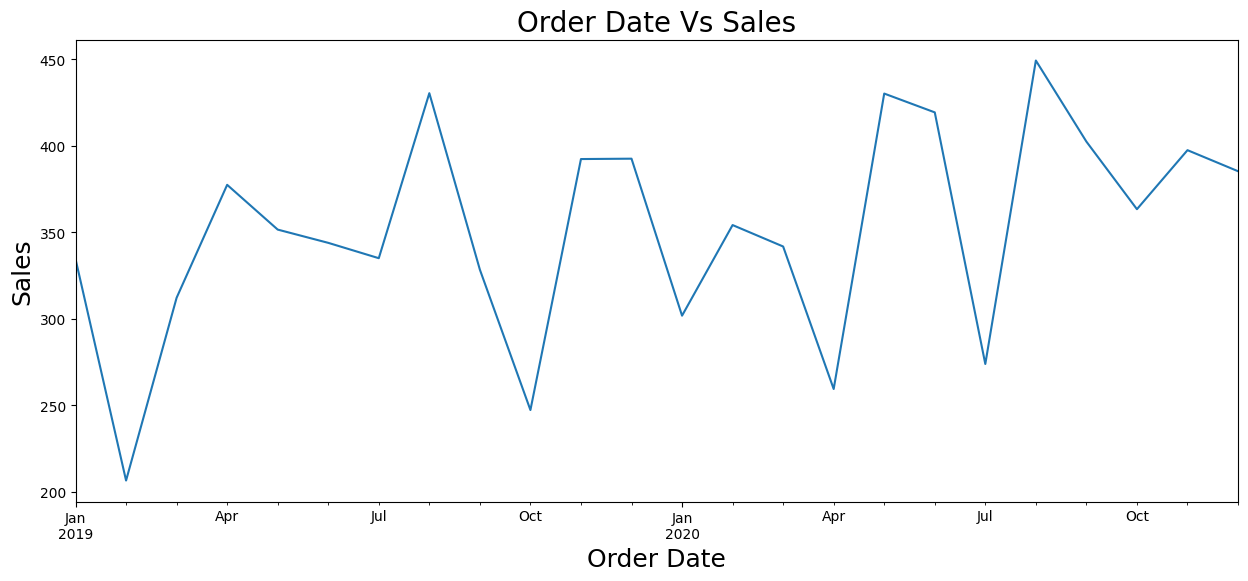

In [20]:
furniture_y.plot(figsize=(15,6))
plt.ylabel("Sales",fontsize=18)
plt.xlabel("Order Date",fontsize=18)
plt.title("Order Date Vs Sales",fontsize=20)
plt.show()

In [21]:
from pylab import rcParams as rc

In [22]:
rc['figure.figsize']= 18, 16

In [23]:
decomposition = sm.tsa.seasonal_decompose(furniture_y,model='additive')

# y(t) = Level + Trend + Seasonality + Noise --> Additive

In [24]:
print("Trend \n ")
print(decomposition.trend)
print("Seasonal \n ")
print(decomposition.seasonal)
print("Residual \n ")
print(decomposition.resid)
print("Observed \n ")
print(decomposition.observed)

Trend 
 
Order Date
2019-01-01           NaN
2019-02-01           NaN
2019-03-01           NaN
2019-04-01           NaN
2019-05-01           NaN
2019-06-01           NaN
2019-07-01    336.376366
2019-08-01    341.162771
2019-09-01    348.548932
2019-10-01    344.867383
2019-11-01    343.226701
2019-12-01    349.643989
2020-01-01    350.237927
2020-02-01    348.476524
2020-03-01    352.346429
2020-04-01    360.265928
2020-05-01    365.315759
2020-06-01    365.227886
2020-07-01           NaN
2020-08-01           NaN
2020-09-01           NaN
2020-10-01           NaN
2020-11-01           NaN
2020-12-01           NaN
Freq: MS, Name: trend, dtype: float64
Seasonal 
 
Order Date
2019-01-01    -50.672617
2019-02-01      3.456199
2019-03-01    -12.803642
2019-04-01   -103.077904
2019-05-01     62.610164
2019-06-01     51.825536
2019-07-01     -3.597158
2019-08-01     86.982491
2019-09-01    -22.391511
2019-10-01    -99.833052
2019-11-01     46.852755
2019-12-01     40.648738
2020-01-01    -50.6

<function matplotlib.pyplot.show(close=None, block=None)>

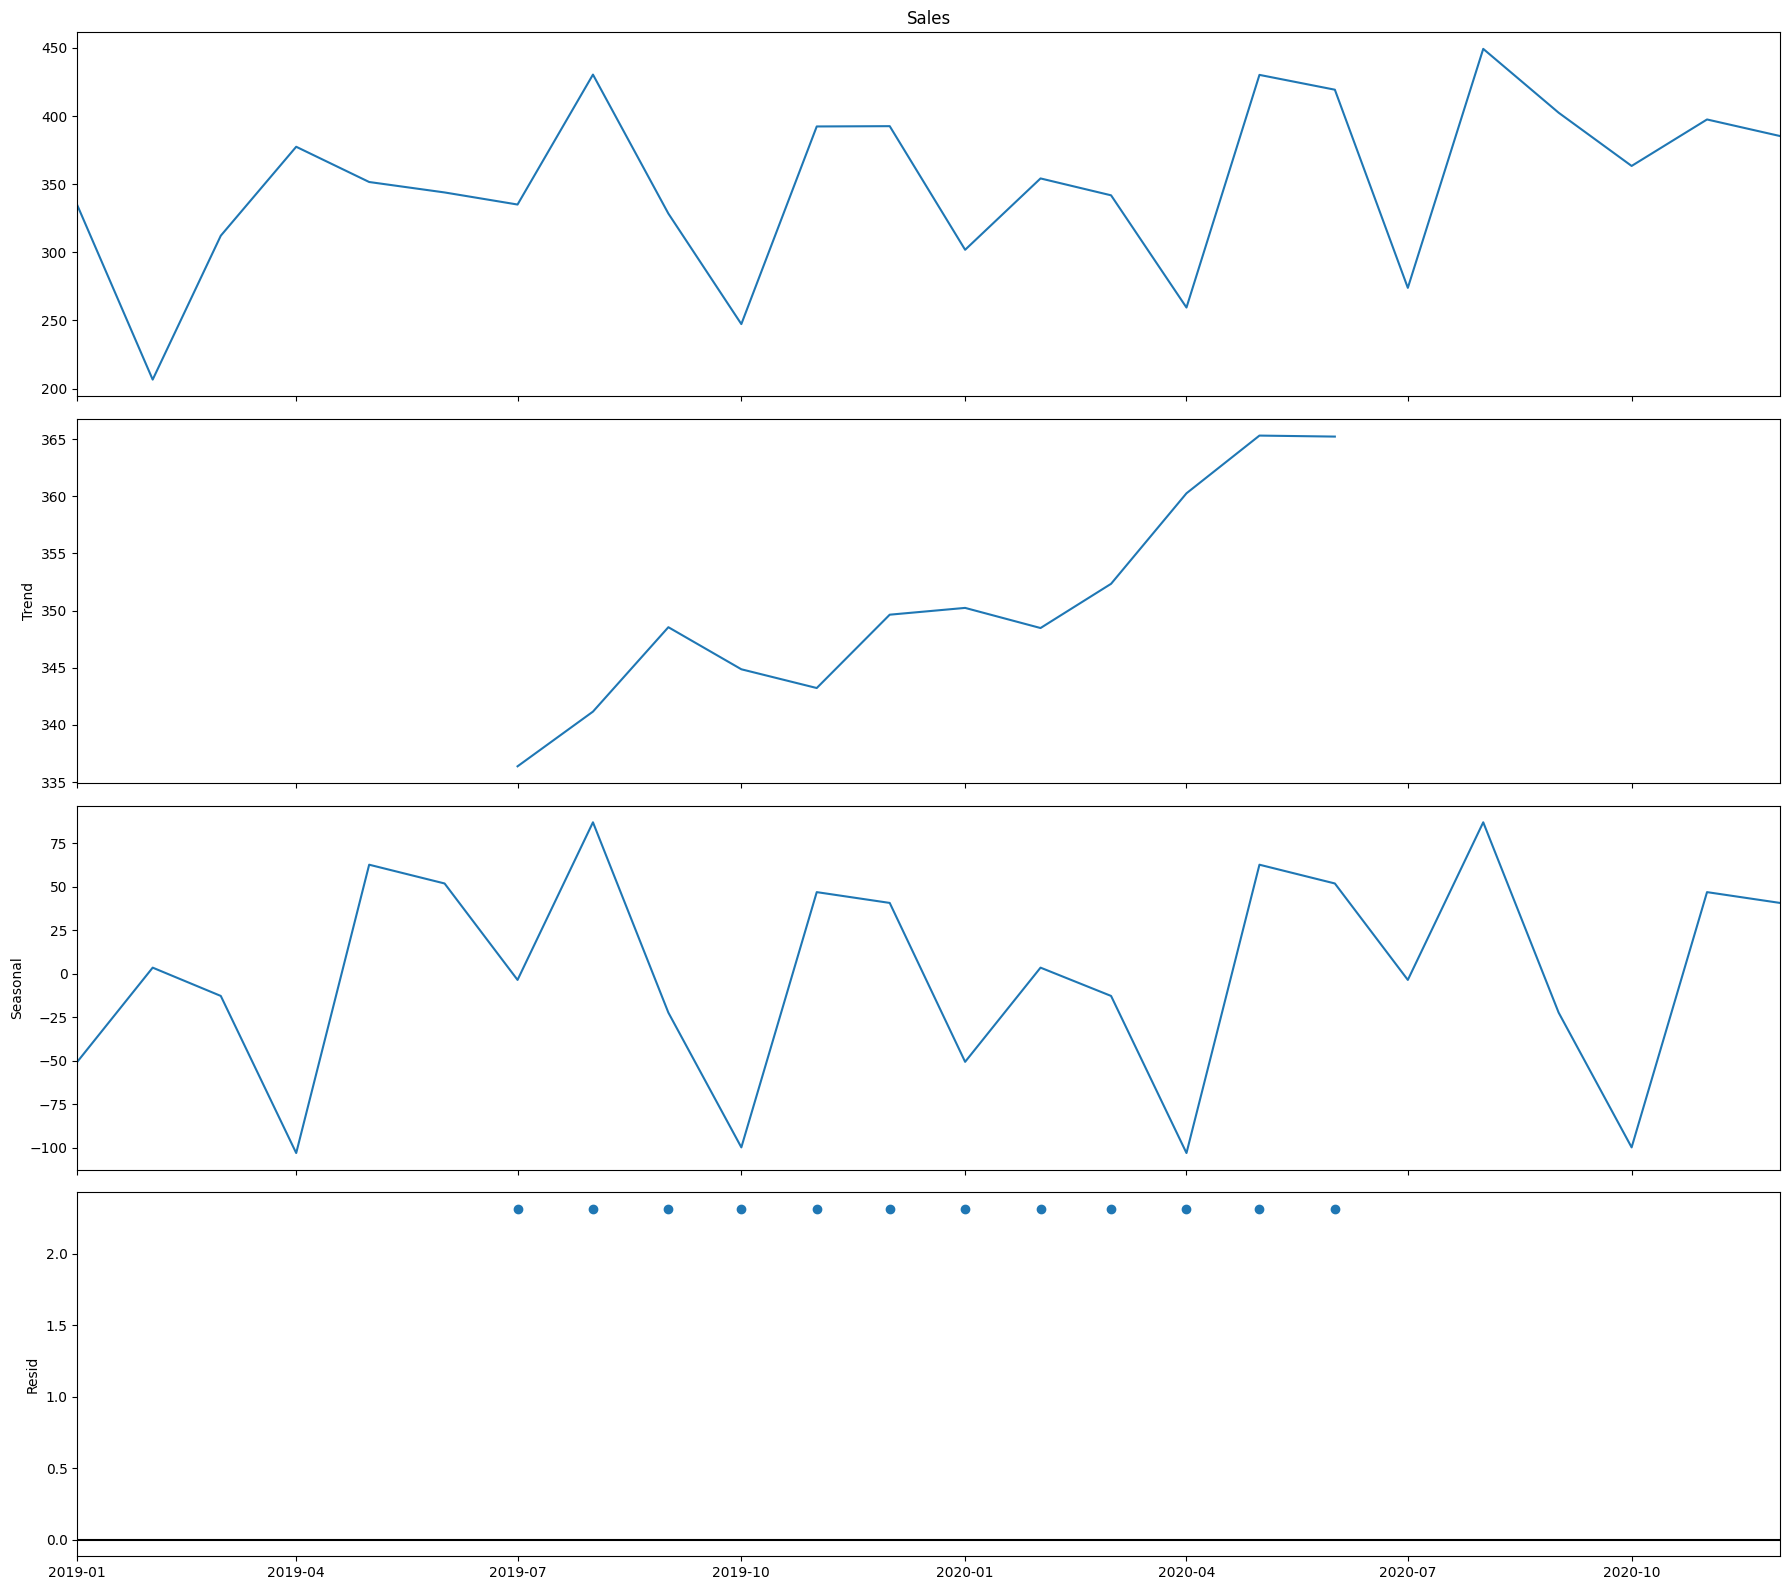

In [25]:
fig = decomposition.plot()
plt.show

# Forecasting With ARIMA

In [26]:
p=d=q=range(0,2)

In [27]:
p,d,q

(range(0, 2), range(0, 2), range(0, 2))

In [28]:
pdq = list(itertools.product(p,d,q))

In [29]:
pdq

[(0, 0, 0),
 (0, 0, 1),
 (0, 1, 0),
 (0, 1, 1),
 (1, 0, 0),
 (1, 0, 1),
 (1, 1, 0),
 (1, 1, 1)]

In [30]:
seasonal_pdq = [(x[1],x[1],x[1], 12) for x in pdq]

In [31]:
seasonal_pdq

[(0, 0, 0, 12),
 (0, 0, 0, 12),
 (1, 1, 1, 12),
 (1, 1, 1, 12),
 (0, 0, 0, 12),
 (0, 0, 0, 12),
 (1, 1, 1, 12),
 (1, 1, 1, 12)]

In [32]:
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(furniture_y,order = param, seasonal_order = param_seasonal ,
                                            enforce_stationarity= False , enforce_invertibility= False )
            results = mod.fit()

            print('ARIMA{} x {} 12 -- AIC : {}'.format(param, param_seasonal, results.aic))

        except:
             continue

ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 337.7046960436404
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 337.7046960436404
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 337.7046960436404
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 337.7046960436404
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 300.9591266923284


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 300.9591266923284
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 300.9591266923284
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 300.9591266923284
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 261.0568640977938


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 261.0568640977938
ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 261.0568640977938
ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 261.0568640977938
ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 239.1565539361509
ARIMA(0, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 239.1565539361509


...

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 241.0487821111729
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 241.0487821111729
ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0
ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 241.0487821111729


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 241.0487821111729
ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0
ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


### ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 254.64207132002917 ---> Best Parameter

In [34]:
mod = sm.tsa.statespace.SARIMAX(furniture_y,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results = mod.fit()
print(results.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2143         -0        inf      0.000      -0.214      -0.214
ma.L1         -0.5596         -0        inf      0.000      -0.560      -0.560
ar.S.L12            0         -0        nan        nan           0           0
sigma2      6381.1372         -0       -inf      0.000    6381.137    6381.137


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tools/eval_measures.py:415: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
/usr/local/lib/python3.10/dist-packages/statsmodels/tools/eval_measures.py:440: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3015: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3015: RuntimeWarning: invalid value encountered in divide
  return self.params / self.bse
/usr

In [35]:
#results.plot_diagnostics(figsize=(16,8))
#plt.show()

ValueError: alpha (7) is outside 0-1 range

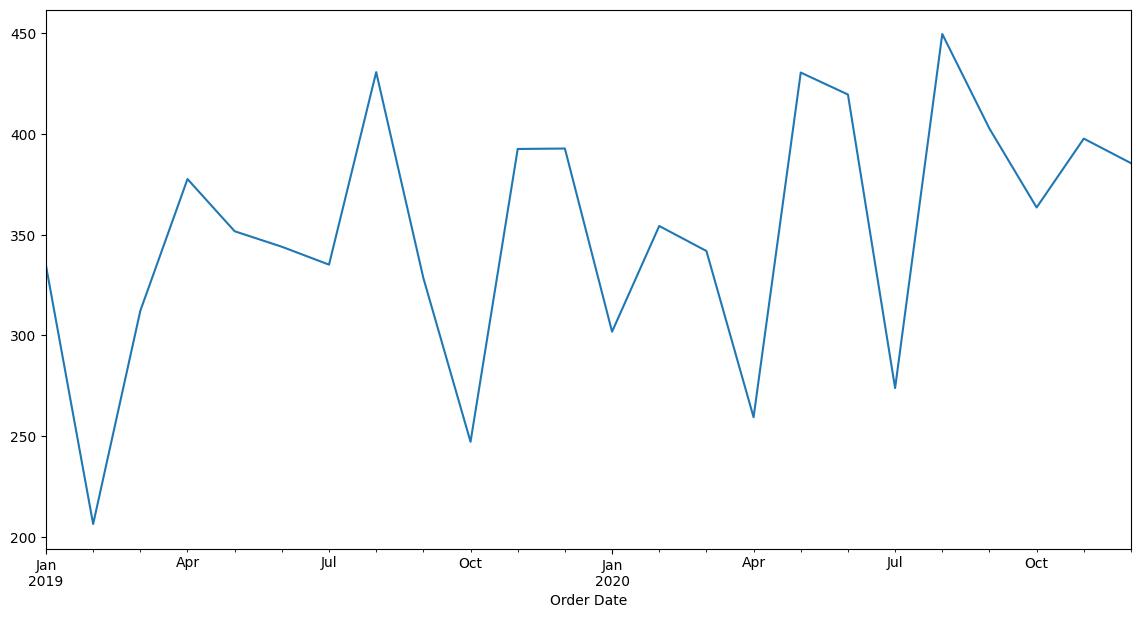

In [63]:
pred = results.get_prediction(start = pd.to_datetime('2020-01-01'), dynamic = False)
pred_ci = pred.conf_int()

ax = furniture_y['2019':].plot(label= 'observed')

pred.predicted_mean.plot(ax = ax, label = 'One step ahead Forecast',alpha=7 , figsize= (14,7))

ax.fill_between(pred_ci.index,
               pred_ci.iloc[:,0],
               pred_ci.iloc[:,1],color = 'k', alpha= 0.2)

ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()

plt.show()

In [38]:
furniture_forecasted = pred.predicted_mean
furn_truth = furniture_y['2020-01-01':]
mse = ((furniture_forecasted - furn_truth) ** 2).mean()

print('MSE of forecast :{}'.format(round(mse,2)))

MSE of forecast :16961.99


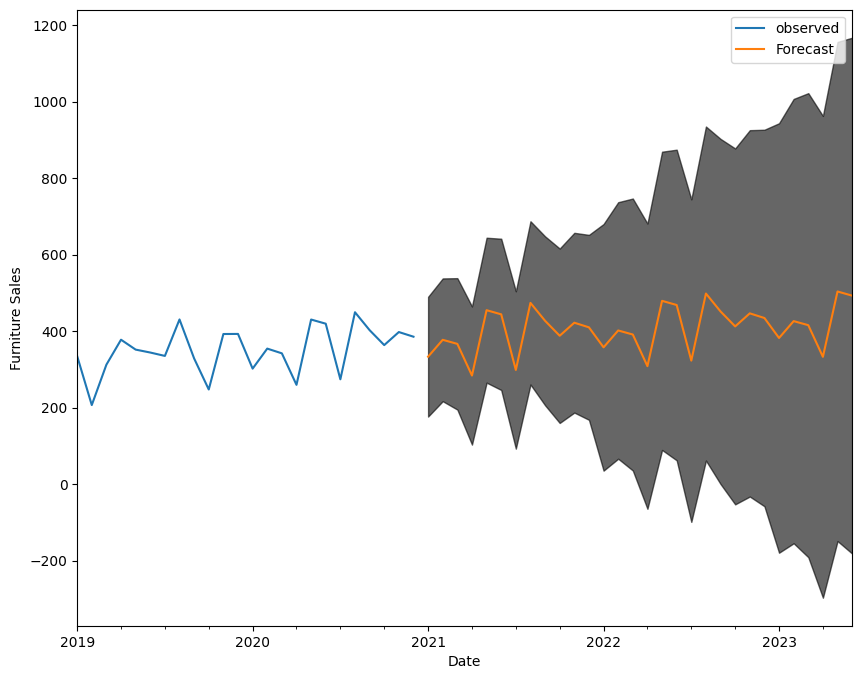

In [42]:
pred_uc = results.get_forecast(steps = 30)
pred_ci = pred_uc.conf_int()

ax = furniture_y.plot(label='observed', figsize=(10,8))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
               pred_ci.iloc[:,0],
               pred_ci.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')

plt.legend()
plt.show()

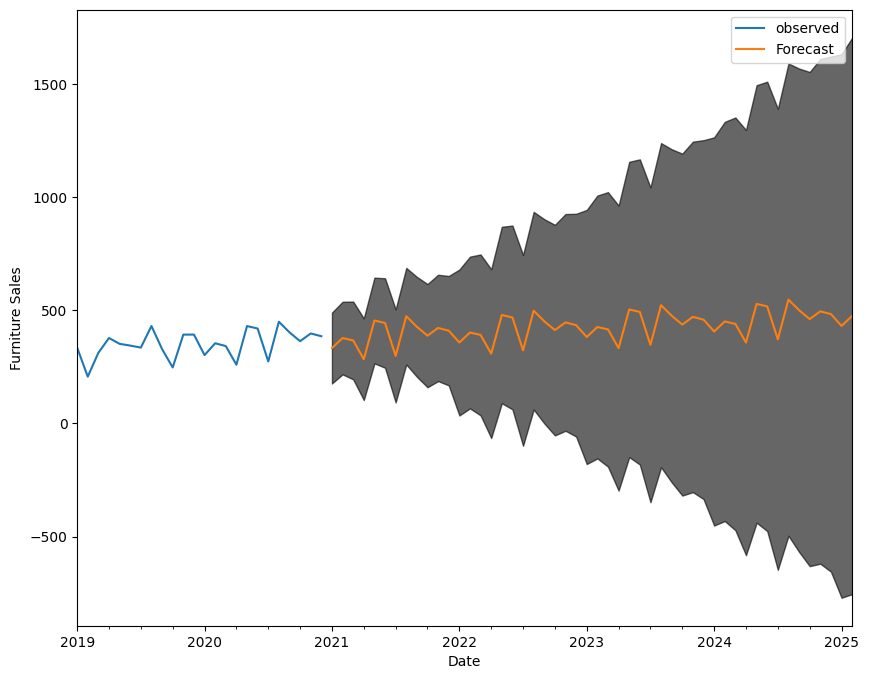

In [41]:
pred_uc = results.get_forecast(steps = 50)
pred_ci = pred_uc.conf_int()

ax = furniture_y.plot(label='observed', figsize=(10,8))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
               pred_ci.iloc[:,0],
               pred_ci.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')

plt.legend()
plt.show()

# Office Supplies Forecast

In [43]:
o_s=df.loc[df['Category']== 'Office Supplies']

In [44]:
o_s

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.460,2,28.6150,0,Online
8,9495,CA-2019-105207,2019-01-03,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,...,Central,OFF-BI-10004364,Office Supplies,Binders,Storex Dura Pro Binders,11.880,2,5.3460,0,COD
10,5868,CA-2019-158211,2019-01-04,2019-01-08,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,...,East,OFF-AR-10004078,Office Supplies,Art,Newell 312,4.672,1,0.5840,0,Online
11,5869,CA-2019-158211,2019-01-04,2019-01-08,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,...,East,OFF-BI-10002026,Office Supplies,Binders,Avery Arch Ring Binders,104.580,6,-80.1780,0,Online
13,864,CA-2019-134474,2019-01-05,2019-01-07,Second Class,AJ-10795,Anthony Johnson,Corporate,United States,Jacksonville,...,South,OFF-AR-10003958,Office Supplies,Art,Newell 337,5.248,2,0.5904,0,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5895,1298,CA-2020-115427,2020-12-30,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,496.720,2,6.4750,1,Online
5897,1297,CA-2020-115427,2020-12-30,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",295.904,2,4.5188,1,Online
5898,5092,CA-2020-156720,2020-12-30,2021-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,388.024,3,-0.6048,0,Online
5899,909,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,462.776,3,19.7910,0,COD


In [45]:
o_s_col = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Quantity', 'Discount', 'Profit']

In [46]:
o_s

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.460,2,28.6150,0,Online
8,9495,CA-2019-105207,2019-01-03,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,...,Central,OFF-BI-10004364,Office Supplies,Binders,Storex Dura Pro Binders,11.880,2,5.3460,0,COD
10,5868,CA-2019-158211,2019-01-04,2019-01-08,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,...,East,OFF-AR-10004078,Office Supplies,Art,Newell 312,4.672,1,0.5840,0,Online
11,5869,CA-2019-158211,2019-01-04,2019-01-08,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,...,East,OFF-BI-10002026,Office Supplies,Binders,Avery Arch Ring Binders,104.580,6,-80.1780,0,Online
13,864,CA-2019-134474,2019-01-05,2019-01-07,Second Class,AJ-10795,Anthony Johnson,Corporate,United States,Jacksonville,...,South,OFF-AR-10003958,Office Supplies,Art,Newell 337,5.248,2,0.5904,0,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5895,1298,CA-2020-115427,2020-12-30,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,496.720,2,6.4750,1,Online
5897,1297,CA-2020-115427,2020-12-30,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",295.904,2,4.5188,1,Online
5898,5092,CA-2020-156720,2020-12-30,2021-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,388.024,3,-0.6048,0,Online
5899,909,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,462.776,3,19.7910,0,COD


In [47]:
os = o_s.sort_values('Order Date')
os = os.set_index('Order Date')

In [48]:
os

,Row ID+O6G3A1:R6,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
Order Date,,,,,,,,,,,,,,,,,,,,
2019-01-03,3074,CA-2019-125206,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.460,2,28.6150,0,Online
2019-01-03,9495,CA-2019-105207,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,Oklahoma,Central,OFF-BI-10004364,Office Supplies,Binders,Storex Dura Pro Binders,11.880,2,5.3460,0,COD
2019-01-04,5868,CA-2019-158211,2019-01-08,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,Pennsylvania,East,OFF-AR-10004078,Office Supplies,Art,Newell 312,4.672,1,0.5840,0,Online
2019-01-04,5869,CA-2019-158211,2019-01-08,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,Pennsylvania,East,OFF-BI-10002026,Office Supplies,Binders,Avery Arch Ring Binders,104.580,6,-80.1780,0,Online
2019-01-05,864,CA-2019-134474,2019-01-07,Second Class,AJ-10795,Anthony Johnson,Corporate,United States,Jacksonville,Florida,South,OFF-AR-10003958,Office Supplies,Art,Newell 337,5.248,2,0.5904,0,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-30,646,CA-2020-126221,2021-01-05,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,509.300,2,56.5110,0,COD
2020-12-30,1298,CA-2020-115427,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,496.720,2,6.4750,1,Online
2020-12-30,1297,CA-2020-115427,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",295.904,2,4.5188,1,Online


In [49]:
os_y = os['Sales'].resample('MS').mean()

In [50]:
os_y.head()

Order Date
2019-01-01    117.770711
2019-02-01    162.382292
2019-03-01    204.081541
2019-04-01     94.225195
2019-05-01     93.108586
Freq: MS, Name: Sales, dtype: float64

In [51]:
os_y.tail()

Order Date
2020-08-01    282.453510
2020-09-01    193.598039
2020-10-01    219.683482
2020-11-01    187.372049
2020-12-01    350.976851
Freq: MS, Name: Sales, dtype: float64

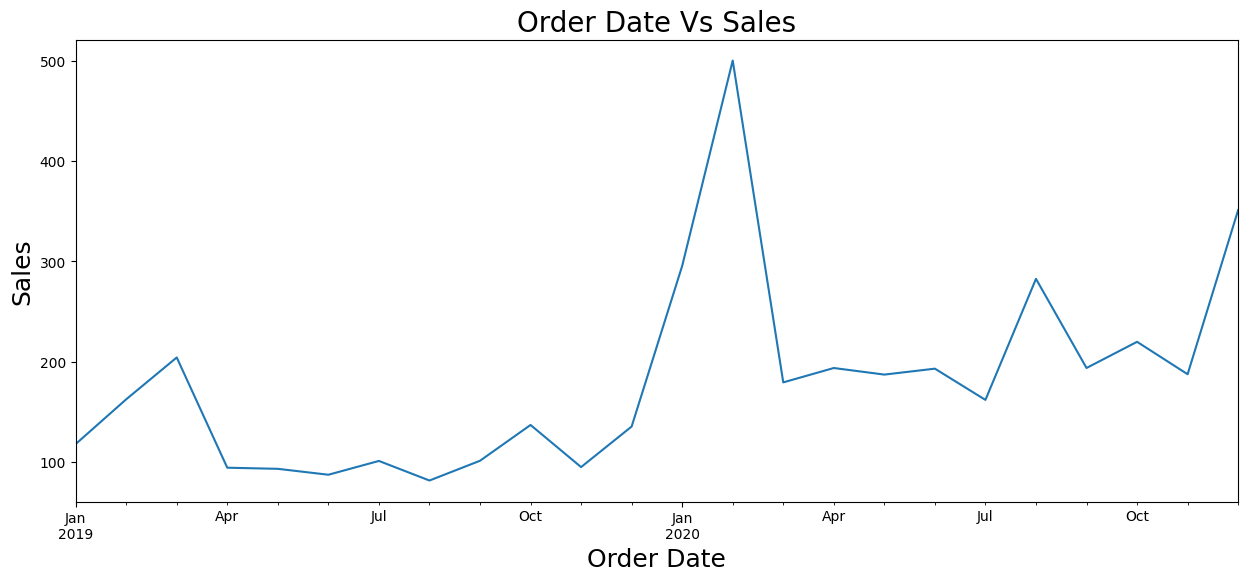

In [52]:
os_y.plot(figsize=(15,6))
plt.ylabel("Sales",fontsize=18)
plt.xlabel("Order Date",fontsize=18)
plt.title("Order Date Vs Sales",fontsize=20)
plt.show()

In [53]:
rc['figure.figsize']= 18, 15

In [54]:
decomposition_os = sm.tsa.seasonal_decompose(os_y,model='additive')

In [55]:
print("Trend \n ")
print(decomposition_os.trend)
print("Seasonal \n ")
print(decomposition_os.seasonal)
print("Residual \n ")
print(decomposition_os.resid)
print("Observed \n ")
print(decomposition_os.observed)

Trend 
 
Order Date
2019-01-01           NaN
2019-02-01           NaN
2019-03-01           NaN
2019-04-01           NaN
2019-05-01           NaN
2019-06-01           NaN
2019-07-01    124.837436
2019-08-01    146.302976
2019-09-01    159.336289
2019-10-01    162.441451
2019-11-01    170.494239
2019-12-01    178.811892
2020-01-01    185.750870
2020-02-01    196.660239
2020-03-01    208.887434
2020-04-01    216.192144
2020-05-01    223.499862
2020-06-01    236.343464
2020-07-01           NaN
2020-08-01           NaN
2020-09-01           NaN
2020-10-01           NaN
2020-11-01           NaN
2020-12-01           NaN
Freq: MS, Name: trend, dtype: float64
Seasonal 
 
Order Date
2019-01-01    110.475321
2019-02-01    304.266147
2019-03-01    -28.723885
2019-04-01    -21.698459
2019-05-01    -35.566259
2019-06-01    -42.503726
2019-07-01    -22.951916
2019-08-01    -63.937493
2019-09-01    -57.276301
2019-10-01    -24.706352
2019-11-01    -74.732428
2019-12-01    -42.644649
2020-01-01    110.4

<function matplotlib.pyplot.show(close=None, block=None)>

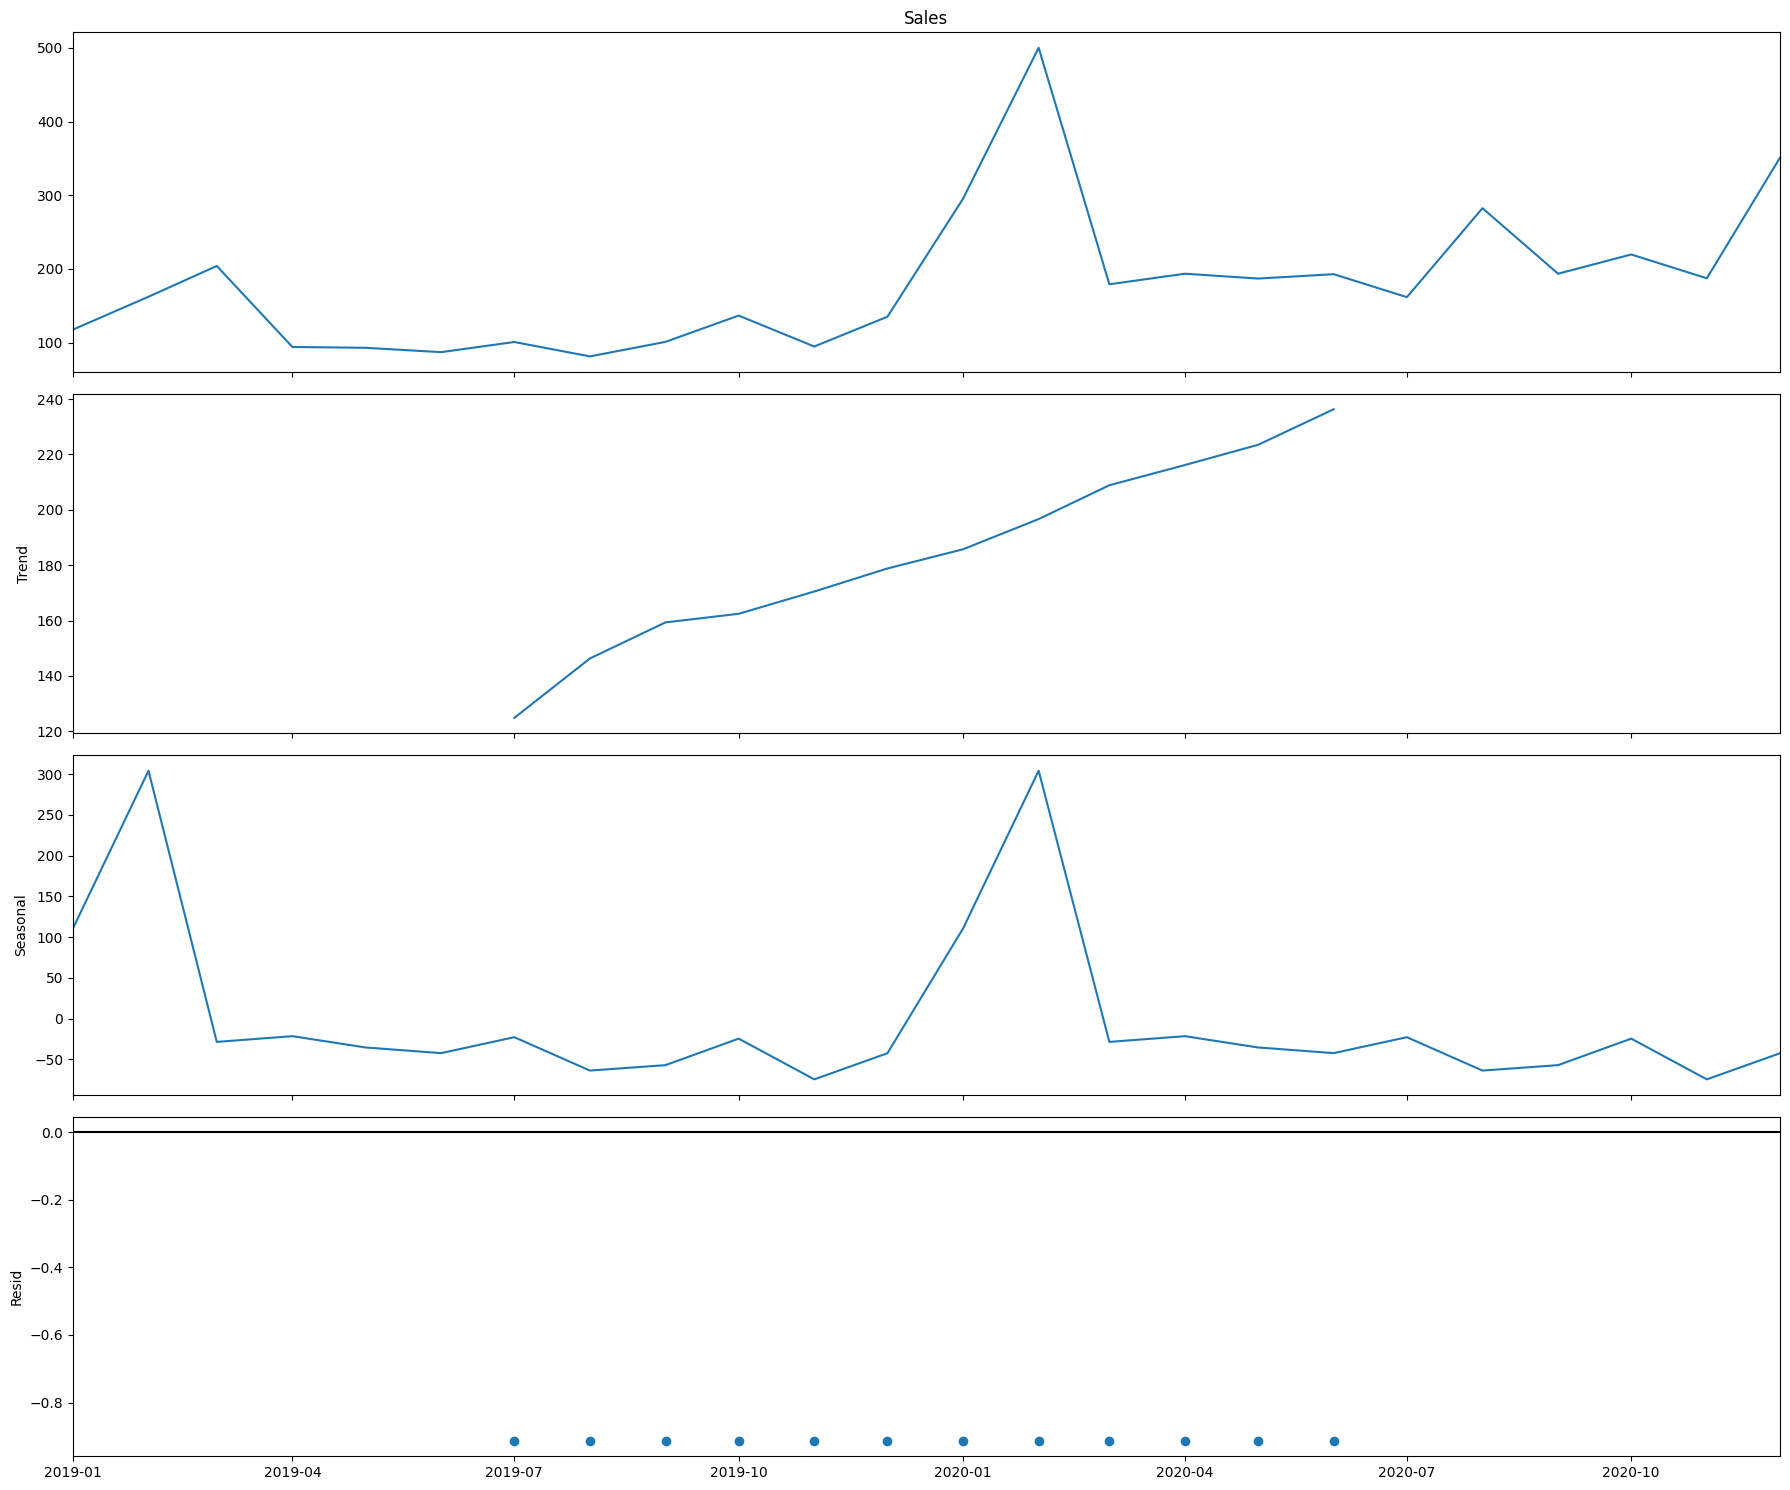

In [56]:
fig = decomposition_os.plot()
plt.show

In [57]:
p=d=q=range(0,2)
pdq = list(itertools.product(p,d,q))
seasonal_pdq = [(x[1],x[1],x[1], 12) for x in pdq]

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(os_y,order = param, seasonal_order = param_seasonal ,
                                            enforce_stationarity= False , enforce_invertibility= False )
            results = mod.fit()

            print('ARIMA{} x {} 12 -- AIC : {}'.format(param, param_seasonal, results.aic))

        except:
             continue

ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 312.8022220513683
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 312.8022220513683
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 312.8022220513683
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 312.8022220513683
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 289.14517079488144


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 289.14517079488144
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 289.14517079488144
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 289.14517079488144
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 0, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 269.164454282229
ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 269.164454282229


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 269.164454282229
ARIMA(0, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 269.164454282229
ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 6.0
ARIMA(0, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 256.3519421088704
ARIMA(0, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 256.3519421088704
ARIMA(0, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 8.0


...

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for va

ARIMA(1, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(1, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(1, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 269.60037711673726
ARIMA(1, 1, 0) x (0, 0, 0, 12) 12 -- AIC : 269.60037711673726
ARIMA(1, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(1, 1, 0) x (1, 1, 1, 12) 12 -- AIC : 8.0
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 257.50401219232594
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 257.50401219232594


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0
ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 257.50401219232594
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 257.50401219232594
ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0
ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 10.0


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [64]:
mod_os = sm.tsa.statespace.SARIMAX(os_y,
                               order=(1,1,1),
                               seasonal_order= (1,1,1,12),
                               enforce_stationarity = False,
                               enforce_invertibility=False)

results_os = mod_os.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [65]:
print(results_os.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0404         -0       -inf      0.000       0.040       0.040
ma.L1         -1.0282         -0        inf      0.000      -1.028      -1.028
ar.S.L12            0         -0        nan        nan           0           0
ma.S.L12            0         -0        nan        nan           0           0
sigma2      3826.6435         -0       -inf      0.000    3826.643    3826.643


/usr/local/lib/python3.10/dist-packages/statsmodels/tools/eval_measures.py:415: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
/usr/local/lib/python3.10/dist-packages/statsmodels/tools/eval_measures.py:440: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3015: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3015: RuntimeWarning: invalid value encountered in divide
  return self.params / self.bse
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/stattools.py:472: RuntimeWarning: Mean of empty slice.
  xo = x - x.mean()
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [66]:
#results_os.plot_diagnostics(figsize=(16,8))
#plt.show()

ValueError: alpha (7) is outside 0-1 range

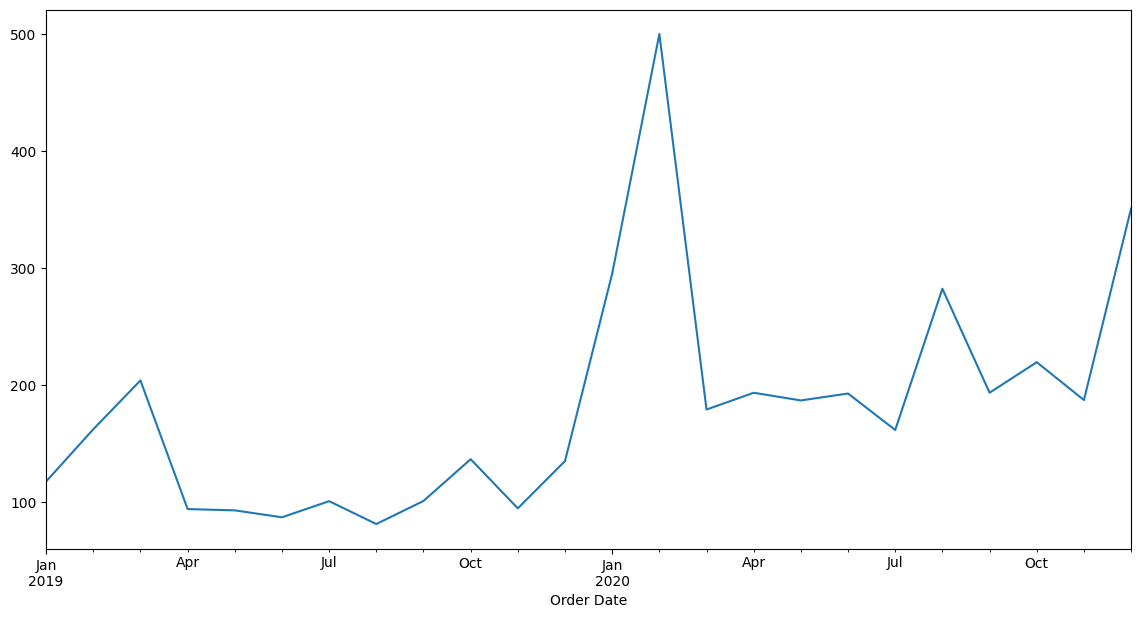

In [80]:
pred_os = results_os.get_prediction(start = pd.to_datetime('2020-01-01'), dynamic = False)
pred_ci_os = pred_os.conf_int()

ax = os_y['2019':].plot(label= 'observed')

pred_os.predicted_mean.plot(ax = ax, label = 'One step ahead Forecast',
                        alpha = 7, figsize= (14,7))

ax.fill_between(pred_ci_os.index,
               pred_ci_os.iloc[:,0],
               pred_ci_os.iloc[:,1],color = 'k', alpha= 1)

ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')
plt.legend()

plt.show()

In [68]:
office_forecasted = pred_os.predicted_mean
office_truth = os_y['2020-01-01':]
mse = ((office_forecasted - office_truth) ** 2).mean()

print('MSE of forecast :{}'.format(round(mse,2)))

MSE of forecast :16418.8


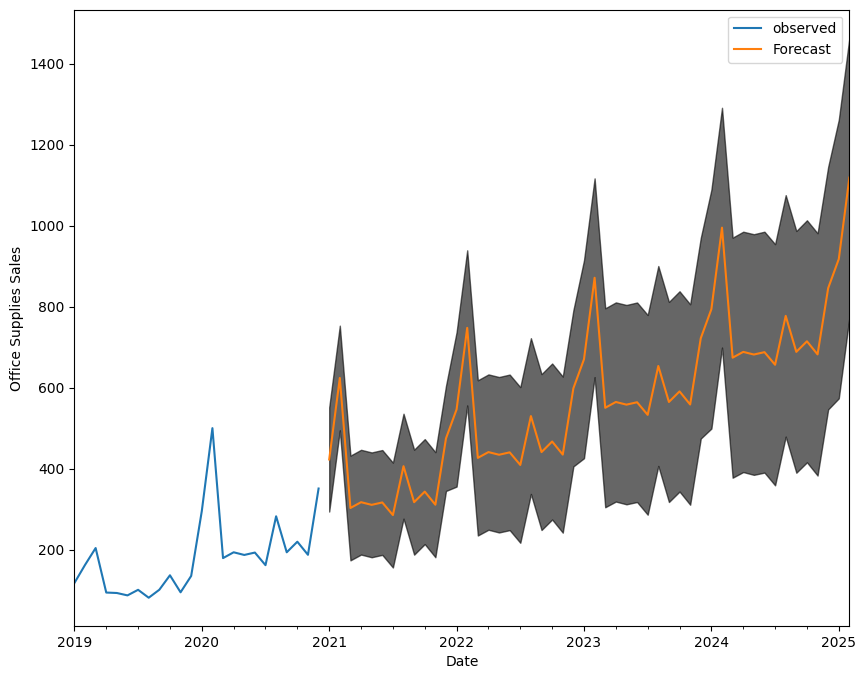

In [73]:
pred_uc_os = results.get_forecast(steps = 50)
pred_ci_os = pred_uc_os.conf_int()

ax = os_y.plot(label='observed', figsize=(10,8))
pred_uc_os.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci_os.index,
               pred_ci_os.iloc[:,0],
               pred_ci_os.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')

plt.legend()
plt.show()

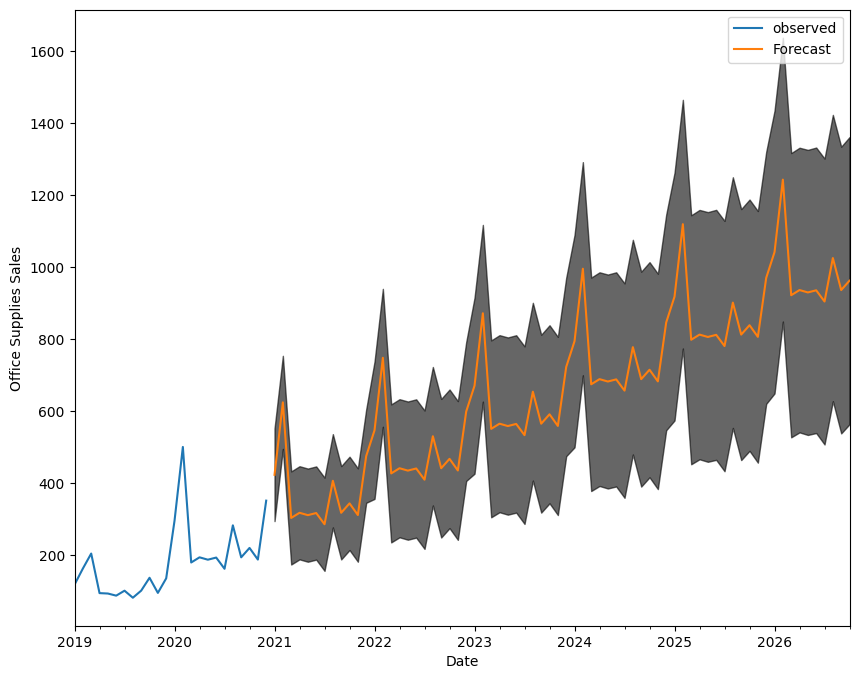

In [72]:
pred_uc_os = results.get_forecast(steps = 70)
pred_ci_os = pred_uc_os.conf_int()

ax = os_y.plot(label='observed', figsize=(10,8))
pred_uc_os.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci_os.index,
               pred_ci_os.iloc[:,0],
               pred_ci_os.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')

plt.legend()
plt.show()